In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import datasets, linear_model
from sklearn import svm
from sklearn.model_selection import train_test_split
from time import time 
from sklearn.metrics import accuracy_score,recall_score,precision_score,confusion_matrix,classification_report

In [5]:
data=pd.read_csv('dataR2.csv')
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             116 non-null    int64  
 1   BMI             116 non-null    float64
 2   Glucose         116 non-null    int64  
 3   Insulin         116 non-null    float64
 4   HOMA            116 non-null    float64
 5   Leptin          116 non-null    float64
 6   Adiponectin     116 non-null    float64
 7   Resistin        116 non-null    float64
 8   MCP.1           116 non-null    float64
 9   Classification  116 non-null    int64  
dtypes: float64(7), int64(3)
memory usage: 9.2 KB


In [6]:
data.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,0
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,0
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,0
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,0
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,0


<Axes: xlabel='Age', ylabel='Classification'>

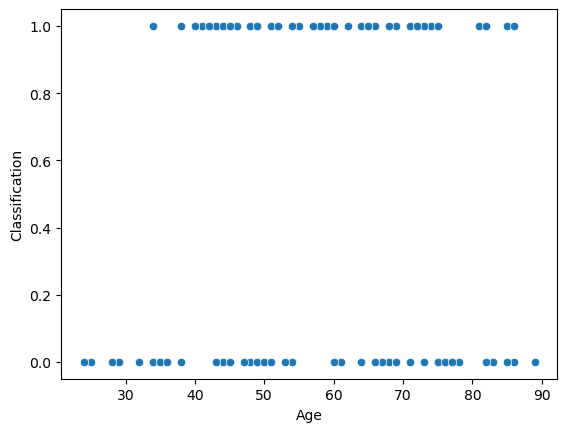

In [7]:
sns.scatterplot(data= data ,x="Age",y="Classification")

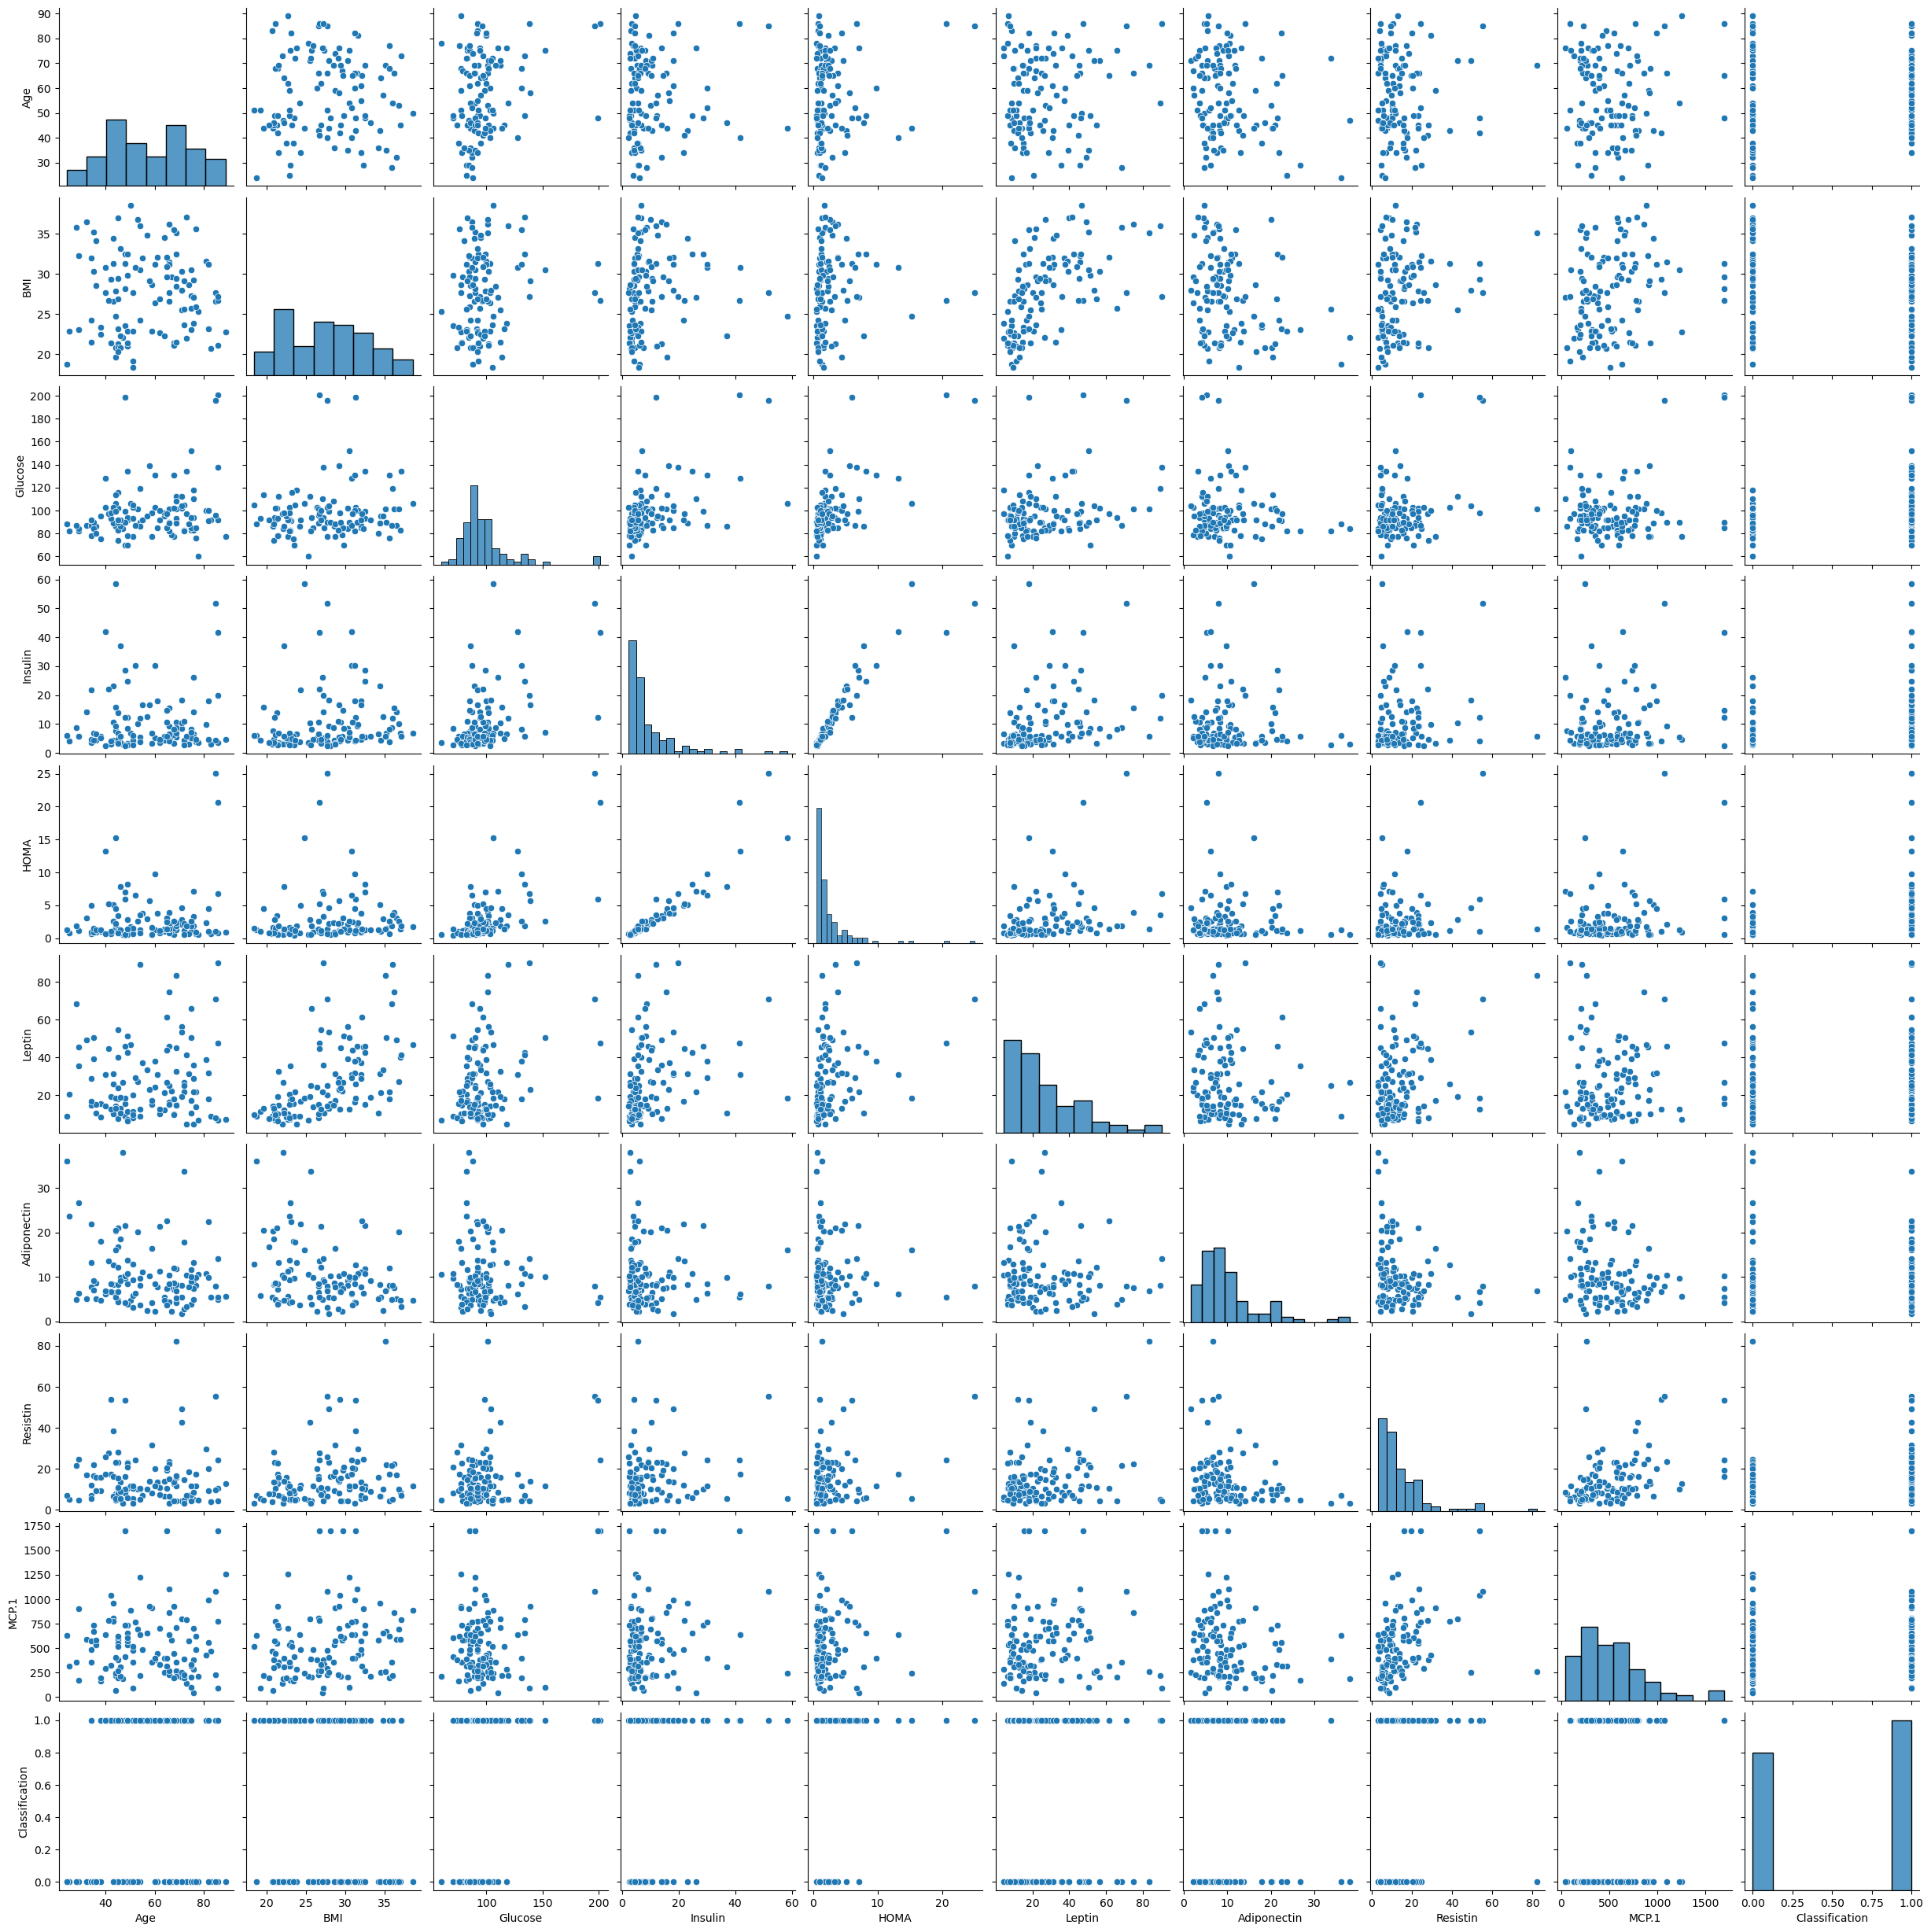

In [9]:
sns.pairplot(data)
plt.show()

In [11]:
x= data.drop(['Classification'],axis=1).values
x

array([[ 48.        ,  23.5       ,  70.        , ...,   9.7024    ,
          7.99585   , 417.114     ],
       [ 83.        ,  20.69049454,  92.        , ...,   5.429285  ,
          4.06405   , 468.786     ],
       [ 82.        ,  23.12467037,  91.        , ...,  22.43204   ,
          9.27715   , 554.697     ],
       ...,
       [ 65.        ,  32.05      ,  97.        , ...,  22.54      ,
         10.33      , 314.05      ],
       [ 72.        ,  25.59      ,  82.        , ...,  33.75      ,
          3.27      , 392.46      ],
       [ 86.        ,  27.18      , 138.        , ...,  14.11      ,
          4.35      ,  90.09      ]])

In [12]:
y = data['Classification'].values
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1], dtype=int64)

In [13]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=.3)

In [14]:
from sklearn.svm import SVC 

In [15]:
svc_model_poly = SVC(kernel="poly")

In [16]:
svc_model_l = SVC(kernel="linear")

In [17]:
svc_model_rbf = SVC(kernel="rbf")

In [18]:
svc_model_sig = SVC(kernel="sigmoid")

In [19]:
svc_model_poly.fit(x_train, y_train)

SVC(kernel='poly')

In [20]:
svc_model_l.fit(x_train, y_train)

SVC(kernel='linear')

In [21]:
svc_model_sig.fit(x_train, y_train)

SVC(kernel='sigmoid')

In [22]:
svc_model_rbf.fit(x_train, y_train)

SVC()

In [23]:
y_pred_l = svc_model_l.predict(x_test)

In [24]:
y_pred_poly = svc_model_poly.predict(x_test)

In [25]:
y_pred_rbf = svc_model_rbf.predict(x_test)

In [26]:
y_pred_sig = svc_model_sig.predict(x_test)

In [31]:
accuracy_score_l= accuracy_score(y_test,y_pred_l)

In [32]:
accuracy_score_poly= accuracy_score(y_test,y_pred_poly)

In [33]:
accuracy_score_rbf= accuracy_score(y_test,y_pred_rbf)

In [34]:
accuracy_score_sig= accuracy_score(y_test,y_pred_sig)

In [36]:
con_l=confusion_matrix(y_test, y_pred_l)
con_poly=confusion_matrix(y_test, y_pred_poly)
con_rbf=confusion_matrix(y_test, y_pred_rbf)
con_sig=confusion_matrix(y_test, y_pred_sig)

In [37]:
print(f"Model_ linear : accuracy = {accuracy_score_l:.2f} \t  confusion= {con_l} \n Model_poly: accuracy= {accuracy_score_poly:.2f} \t confusion= {con_poly} \n Model_rbf: accuracy= {accuracy_score_rbf:.2f}\t confusion={con_rbf} \n Model_sig: accuracy= {accuracy_score_sig:.2f} \t confusion= ") 

Model_ linear : accuracy = 0.80 	  confusion= [[16  0]
 [ 7 12]] 
 Model_poly: accuracy= 0.5428571428571428 	 confusion= [[ 0 16]
 [ 0 19]] 
 Model_rbf: accuracy= 0.5428571428571428	 confusion=[[ 0 16]
 [ 0 19]] 
 Model_sig: accuracy= [[ 0 16]
 [ 0 19]]
